# Clase 1 — Procesamiento de audio: espectrogramas y features acústicas

## Pregunta central

> **¿Cómo convertimos una señal de audio en números que una computadora pueda analizar?**

## Idea principal

El audio es una secuencia de amplitudes en el tiempo. Para analizarlo con software, lo convertimos en representaciones numéricas: la onda (waveform), el espectrograma (frecuencias en el tiempo) y features acústicas (números resumen).

## Objetivos de aprendizaje

Al finalizar la clase deberías poder:

- Leer un archivo WAV y describir su sample rate, duración y canales.
- Visualizar una waveform e interpretar silencios y amplitudes.
- Explicar qué muestra un espectrograma y por qué es útil.
- Calcular features acústicas simples (RMS, zero-crossing, duración de silencios).
- Decidir qué representación usar según el problema.

## Recorrido de la clase

| Paso | Tema |
|---:|---|
| 1 | Audio digital: muestras y sample rate |
| 2 | La waveform: amplitud en el tiempo |
| 3 | El espectrograma: frecuencias en el tiempo |
| 4 | Features acústicas: números que resumen |
| 5 | Aplicación en salud: silencios y calidad |
| 6 | Actividad: preparar un audio para una aplicación |

## Cómo trabajar con este notebook

1. Ejecutá las celdas en el orden propuesto.
2. Antes de modificar código, observá y describí el resultado.
3. Cambiá solamente las variables marcadas con `TODO`.
4. No es necesario implementar algoritmos desde cero.
5. Si aparece un término nuevo, buscá primero su definición en el glosario de la clase.

**Conexión con el programa:** el audio es la entrada de los asistentes conversacionales del Track Salud. En la clase 2 veremos cómo un modelo (Whisper) convierte esta señal en texto.


## Glosario mínimo

| Término | Explicación breve |
|---|---|
| Sample rate | Cantidad de muestras de audio por segundo (Hz) |
| Muestra | Un valor de amplitud en un instante |
| Waveform | Secuencia de amplitudes a lo largo del tiempo |
| Amplitud | Qué tan fuerte es la señal en un instante |
| Espectrograma | Mapa de frecuencias presentes en cada momento |
| STFT | Transformada que divide el audio en ventanas y calcula frecuencias |
| Feature acústica | Número resumen calculado sobre el audio |
| RMS | Energía promedio de la señal (raíz cuadrada media) |
| Zero-crossing | Cantidad de veces que la señal cruza el cero |
| Silencio | Región con amplitud muy baja |
| PCM | Forma de guardar audio como valores de amplitud |
| Mono | Un solo canal de audio |
| Tono puro | Señal con una sola frecuencia (ej. 440 Hz) |

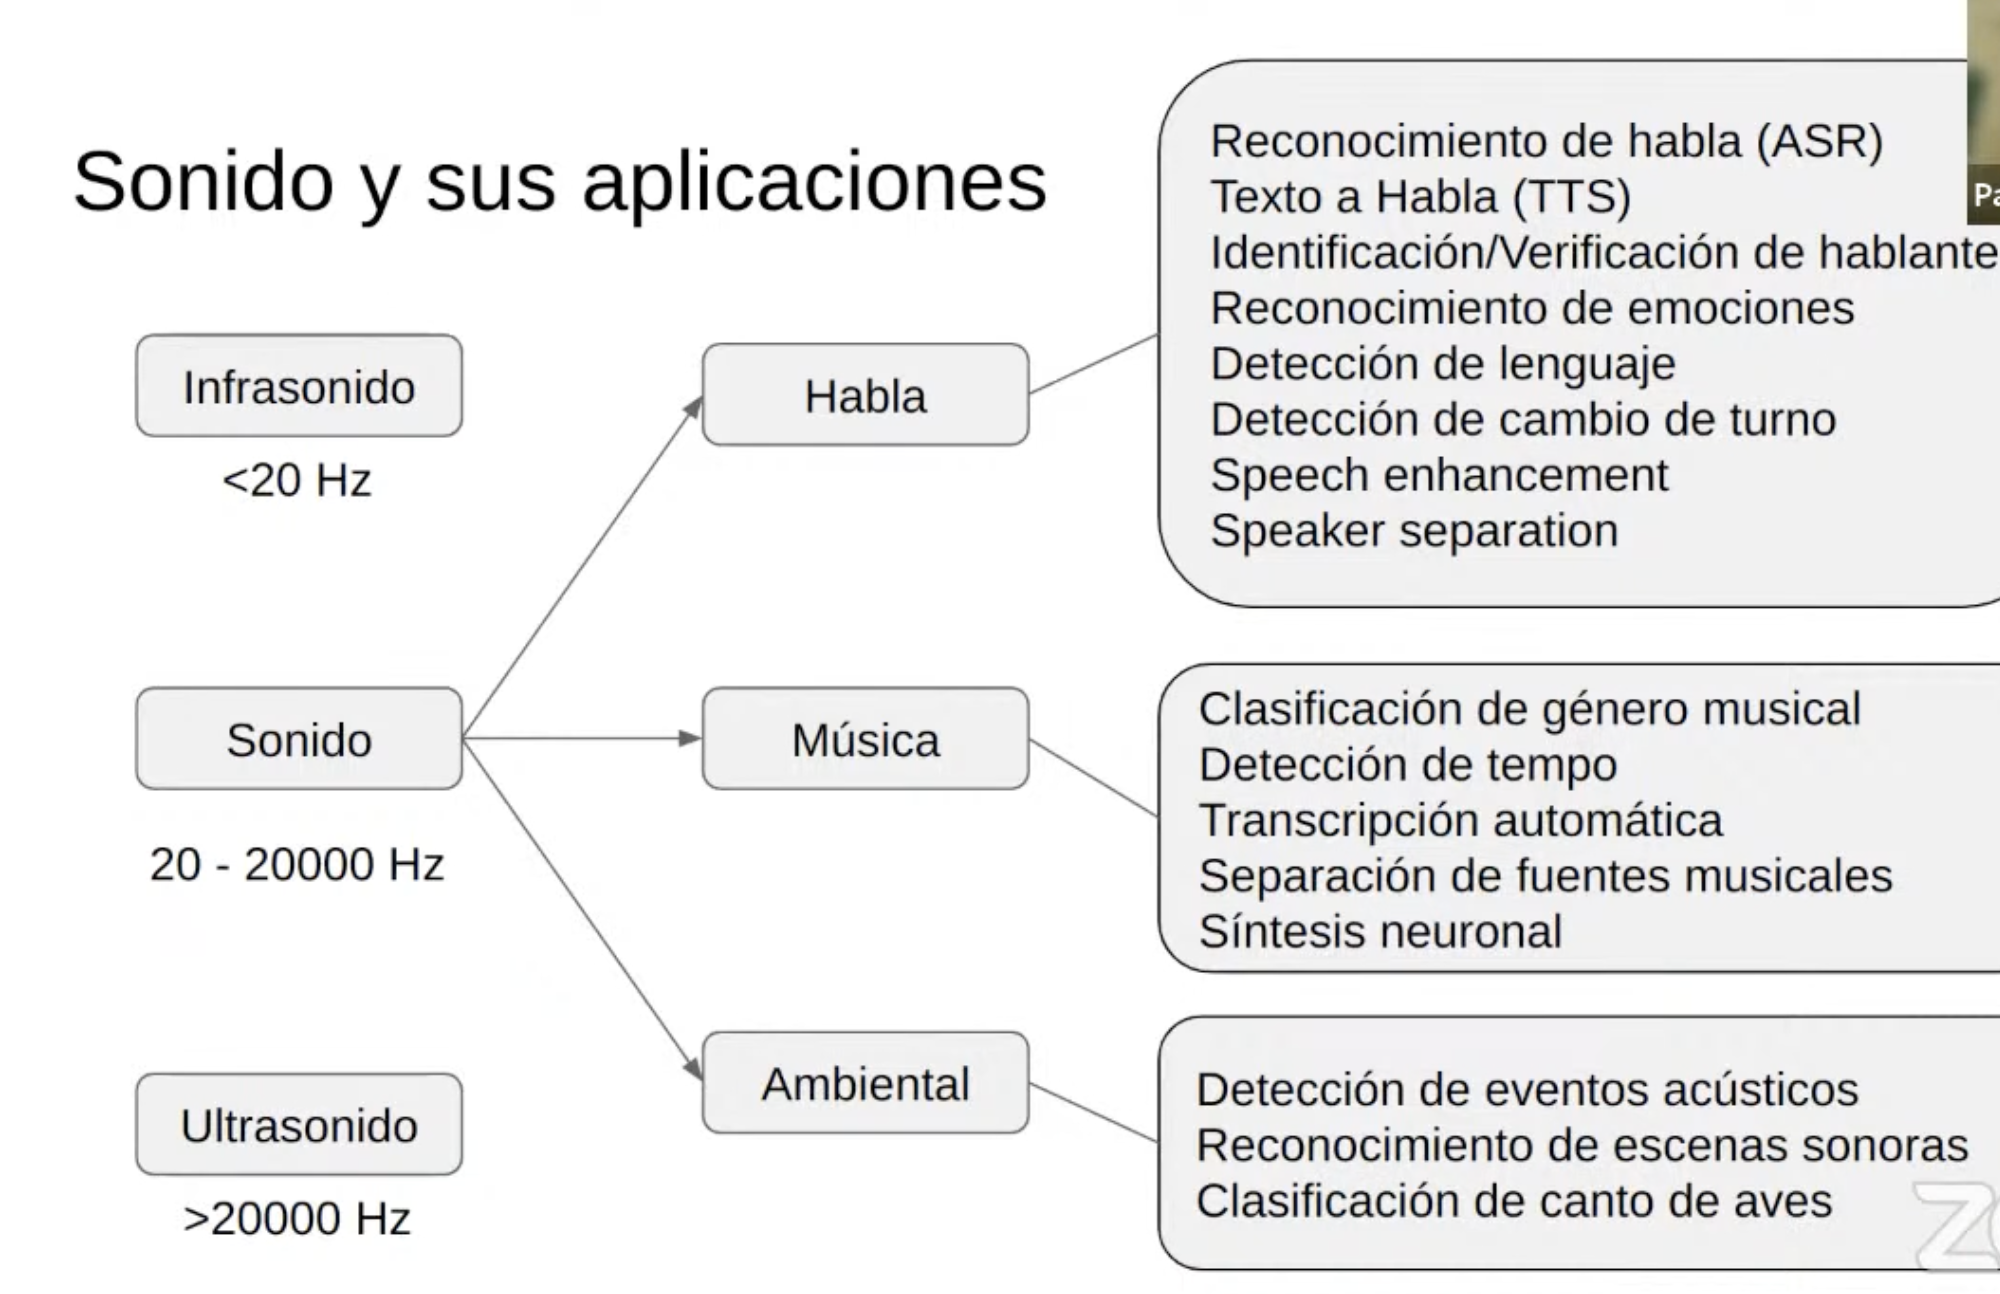

---
## 1. Audio digital: muestras y sample rate

Una computadora no guarda "sonido": guarda **mediciones de amplitud** tomadas a intervalos regulares. Cada medición es una **muestra**.

> **Analogía del fotograma.** Un video es una secuencia de fotos. El audio digital es una secuencia de "fotogramas de sonido": muestras de amplitud. Cuantas más muestras por segundo, más fiel es la representación.

| Concepto | Valor típico en este curso |
|---|---|
| Sample rate | 16.000 Hz (16 kHz) |
| Canales | 1 (mono) |
| Formato | PCM, valores entre -1 y 1 |
| Duración | Depende del archivo |

El **sample rate** define cuántas muestras hay por segundo. Un audio de 3 segundos a 16 kHz tiene 48.000 muestras.

> **Pensalo así:** si el sample rate es bajo, perdemos detalle de la señal. Si es alto, el archivo pesa más. 16 kHz alcanza para voz humana, que es lo que usamos en salud.


In [35]:
# --- Leer un archivo WAV ---
import os
import numpy as np
import soundfile as sf

# Ruta del audio de ejemplo provisto para la clase.
RUTA_AUDIO = os.path.join("..", "assets", "audio", "taxi.wav")

# soundfile devuelve el arreglo de muestras y el sample rate.
audio, sr = sf.read(RUTA_AUDIO)

duracion = len(audio) / sr
print("Archivo:", os.path.basename(RUTA_AUDIO))
print(f"Sample rate: {sr} Hz")
print(f"Muestras: {len(audio):,}")
print(f"Duración: {duracion:.2f} s")
print(f"Canales: {audio.ndim} (1 = mono)")
print(f"Rango de amplitud: [{audio.min():.3f}, {audio.max():.3f}]")


Archivo: taxi.wav
Sample rate: 16000 Hz
Muestras: 486,087
Duración: 30.38 s
Canales: 1 (1 = mono)
Rango de amplitud: [-0.912, 0.849]


### ¿Qué significa cada número?

El arreglo `audio` es un vector de números. Cada número es la **amplitud** de la señal en un instante:

```text
muestra 0 -> amplitud en t = 0.000 s
muestra 1 -> amplitud en t = 0.0000625 s  (1/16000)
muestra 2 -> amplitud en t = 0.000125 s
...
```

> **Pensalo así:** el audio es una serie de tiempo. El eje horizontal es el tiempo y el vertical es la amplitud. Eso es exactamente lo que dibuja la waveform.


In [36]:
# --- Primeras muestras del audio ---
# Mostramos las primeras 10 muestras para "ver" los números.
primeras = audio[:10]
print("Primeras 10 muestras:")
for i, valor in enumerate(primeras):
    print(f"  t={i/sr*1000:7.2f} ms  amplitud={valor:+.4f}")


Primeras 10 muestras:
  t=   0.00 ms  amplitud=+0.0000
  t=   0.06 ms  amplitud=+0.0000
  t=   0.12 ms  amplitud=+0.0000
  t=   0.19 ms  amplitud=+0.0000
  t=   0.25 ms  amplitud=+0.0000
  t=   0.31 ms  amplitud=+0.0000
  t=   0.38 ms  amplitud=+0.0000
  t=   0.44 ms  amplitud=+0.0000
  t=   0.50 ms  amplitud=+0.0000
  t=   0.56 ms  amplitud=+0.0000


---
## 2. La waveform: amplitud en el tiempo

La **waveform** es el gráfico más directo del audio: amplitud en el eje vertical, tiempo en el horizontal.

> **Analogía del electrocardiograma.** Así como un ECG muestra la actividad del corazón en el tiempo, la waveform muestra la actividad del sonido. Los picos son sonidos fuertes; las zonas planas cerca de cero son silencios.


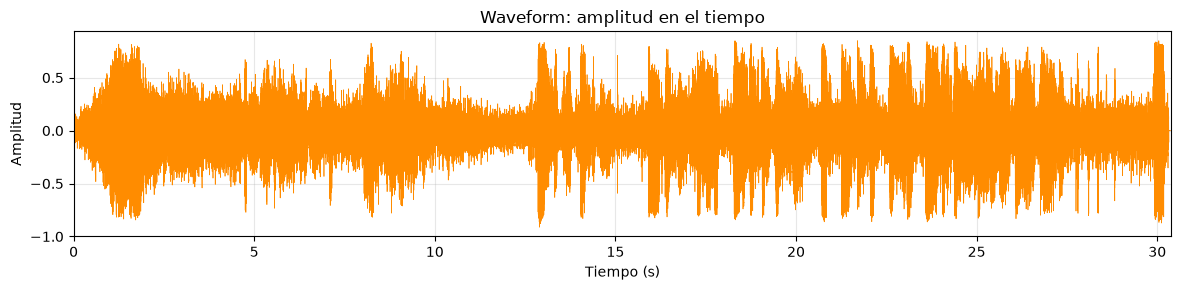

In [37]:
# --- Visualizar la waveform completa ---
import matplotlib.pyplot as plt

# Eje de tiempo en segundos.
tiempo = np.arange(len(audio)) / sr

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(tiempo, audio, color="darkorange", lw=0.5)
ax.set_title("Waveform: amplitud en el tiempo")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.set_xlim(0, duracion)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Qué observar en la waveform

- **Zonas con amplitud alta:** hay sonido (voz hablando).
- **Zonas planas cerca de cero:** silencio o pausas.
- **Picos:** sílabas o sonidos fuertes.

> **Pregunta de interpretación:** ¿Cuántas pausas ves? ¿Dónde empieza y termina la voz? Esas pausas son información: en una llamada de consultorio, marcan turnos de habla.


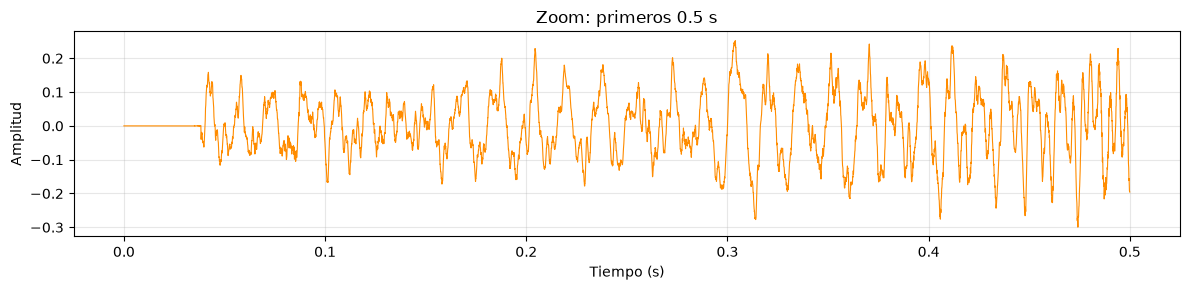

In [38]:
# --- Zoom: primeros 0.5 segundos ---
# Acercamos para ver la forma de la onda con detalle.
n_zoom = int(0.5 * sr)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(tiempo[:n_zoom], audio[:n_zoom], color="darkorange", lw=0.8)
ax.set_title("Zoom: primeros 0.5 s")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## 3. El espectrograma: frecuencias en el tiempo

La waveform muestra **cuánta** amplitud hay, pero no **qué frecuencias** la componen. El **espectrograma** responde esa pregunta: muestra qué frecuencias están presentes en cada momento.

> **Analogía del coro.** Una waveform es como ver la silueta del coro completo. El espectrograma es como poder distinguir cada voz: los bajos abajo, los agudos arriba. La voz humana tiene energía concentrada en frecuencias bajas y medias.

Para calcularlo usamos la **STFT** (Short-Time Fourier Transform): dividimos el audio en ventanas cortas y, en cada ventana, calculamos qué frecuencias hay.

```text
audio completo
    |
    v
ventanas de ~25 ms
    |
    v
para cada ventana: frecuencias presentes
    |
    v
matriz: tiempo x frecuencia (intensidad = color)
```


In [39]:
# --- Calcular el espectrograma con scipy ---
from scipy.signal import butter, spectrogram, sosfiltfilt

# Parámetros de la STFT.
# - nperseg: tamaño de cada ventana en muestras (25 ms a 16 kHz = 400 muestras).
# - noverlap: solapamiento entre ventanas (75%).
ventana = 400
solape = 300

frecuencias, tiempos_esp, Sxx = spectrogram(
    audio, fs=sr, nperseg=ventana, noverlap=solape
)

print("Forma del espectrograma:", Sxx.shape)
print(f"  - {Sxx.shape[0]} bandas de frecuencia (hasta {frecuencias[-1]:.0f} Hz)")
print(f"  - {Sxx.shape[1]} instantes de tiempo")


Forma del espectrograma: (201, 4857)
  - 201 bandas de frecuencia (hasta 8000 Hz)
  - 4857 instantes de tiempo


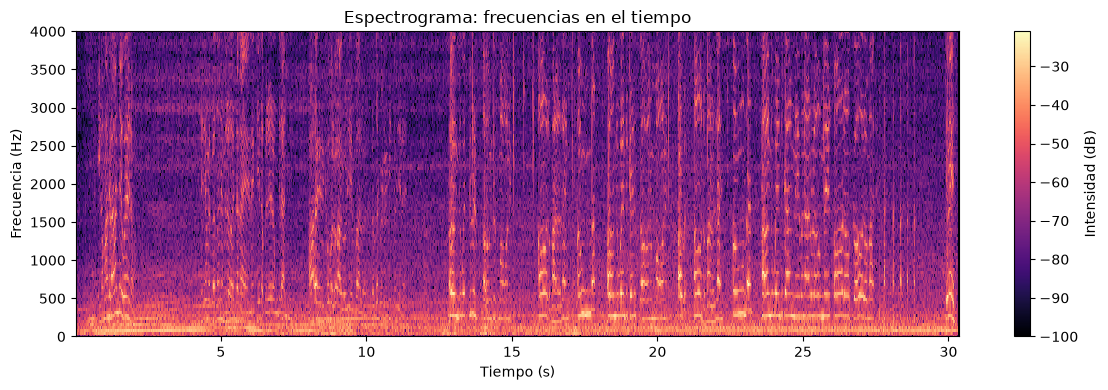

In [40]:
# --- Visualizar el espectrograma ---
fig, ax = plt.subplots(figsize=(12, 4))
# Mostramos la intensidad en escala logarítmica (dB) para que se vea mejor.
im = ax.pcolormesh(
    tiempos_esp, frecuencias, 10 * np.log10(Sxx + 1e-10),
    shading="auto", cmap="magma"
)
ax.set_title("Espectrograma: frecuencias en el tiempo")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_ylim(0, 4000)  # La voz humana está por debajo de 4 kHz.
fig.colorbar(im, ax=ax, label="Intensidad (dB)")
plt.tight_layout()
plt.show()


### Qué observar en el espectrograma

- **Eje horizontal:** tiempo.
- **Eje vertical:** frecuencia (0 a 4 kHz para voz).
- **Color:** intensidad. Más claro = más energía en esa frecuencia.

> **Pregunta de interpretación:** ¿Dónde está la energía de la voz? ¿Hay bandas horizontales (tonos sostenidos) o cambios rápidos (consonantes)? Las vocales aparecen como bandas horizontales; las consonantes como ráfagas verticales.

> **Pensalo así:** el espectrograma es la "huella digital" del audio. Modelos como Whisper lo usan como entrada para reconocer el habla.


---
## 4. Features acústicas: números que resumen

Un espectrograma es una matriz grande. Para comparar audios o entrenar modelos simples, conviene **resumir** el audio en números: las **features acústicas**.

| Feature | Qué mide | Para qué sirve |
|---|---|---|
| RMS | Energía promedio | Distinguir voz de silencio |
| Zero-crossing rate | Cuántas veces cruza el cero | Distinguir voz de tono puro |
| Duración de silencios | Tiempo con amplitud baja | Detectar pausas en llamadas |
| Amplitud máxima | Pico más fuerte | Detectar clipping o ruido fuerte |


In [41]:
# --- Funciones de features acústicas ---
def rms(señal):
    """Energía promedio (raíz cuadrada media)."""
    return float(np.sqrt(np.mean(señal ** 2)))

def zero_crossing_rate(señal):
    """Fracción de muestras donde la señal cambia de signo."""
    cambios = np.diff(np.signbit(señal))
    return float(np.mean(cambios))

def duracion_silencios(señal, sr, umbral=0.02):
    """Fracción de tiempo con amplitud por debajo del umbral."""
    silencio = np.abs(señal) < umbral
    return float(np.mean(silencio))

# Calculamos las features del audio demo.
features_audio = {
    "RMS": rms(audio),
    "Zero-crossing rate": zero_crossing_rate(audio),
    "Fracción de silencio": duracion_silencios(audio, sr),
    "Amplitud máxima": float(np.max(np.abs(audio))),
}

print("Features del audio demo:")
for nombre, valor in features_audio.items():
    print(f"  {nombre:22s} {valor:.4f}")


Features del audio demo:
  RMS                    0.2185
  Zero-crossing rate     0.0582
  Fracción de silencio   0.0921
  Amplitud máxima        0.9120


### Comparar con un tono puro

Para entender qué mide cada feature, comparamos el audio demo con un **tono puro** (una sola frecuencia, como un diapasón).

> **Pregunta de interpretación:** ¿Qué esperás que cambie? Un tono puro no tiene silencios, cruza el cero de forma muy regular y su energía es constante.


In [42]:
# --- Generar un tono puro de 440 Hz (la nota "la") ---
import numpy as np

duracion_tono = 3.0
t_tono = np.arange(int(duracion_tono * sr)) / sr
tono = 0.5 * np.sin(2 * np.pi * 440 * t_tono)

features_tono = {
    "RMS": rms(tono),
    "Zero-crossing rate": zero_crossing_rate(tono),
    "Fracción de silencio": duracion_silencios(tono, sr),
    "Amplitud máxima": float(np.max(np.abs(tono))),
}

# Tabla comparativa.
import pandas as pd
tabla = pd.DataFrame([features_audio, features_tono], index=["audio demo", "tono 440 Hz"])
tabla.round(4)


,RMS,Zero-crossing rate,Fracción de silencio,Amplitud máxima
audio demo,0.2185,0.0582,0.0921,0.912
tono 440 Hz,0.3536,0.0550,0.0250,0.500


### Interpretar la tabla

| Feature | Voz | Tono puro | Por qué |
|---|---|---|---|
| RMS | Variable | Constante | La voz tiene pausas y sílabas |
| Zero-crossing | Alto | Bajo | La voz tiene muchas transiciones |
| Fracción de silencio | > 0 | ~ 0 | La voz tiene pausas; el tono no |
| Amplitud máxima | ~ 0.7 | 0.5 | Depende del volumen de cada uno |

> **Pensalo así:** cada feature es una "pregunta" distinta al audio. Una sola no alcanza; combinarlas permite distinguir tipos de sonido.


---
## 5. Aplicación en salud: silencios y calidad

Estas features tienen usos concretos en aplicaciones de consultorios:

| Problema | Feature útil | Ejemplo |
|---|---|---|
| Detectar turnos de habla | Fracción de silencio | Saber cuándo habla el paciente y cuándo el profesional |
| Calidad de grabación | RMS y amplitud máxima | Detectar audios muy bajos o con clipping |
| Detectar ruido de fondo | Zero-crossing alto en silencios | Alertar que la grabación tiene ruido |
| Voz vs. tono de espera | Zero-crossing + silencios | No transcribir la música de espera |

> **Importante:** estas features son **heurísticas**: reglas simples que funcionan en muchos casos, pero no siempre. No reemplazan a un modelo, pero son baratas, rápidas y explicables.


---
## 6. Actividad — preparar un audio para una aplicación

**Duración sugerida:** 30 minutos.

### El caso

Una aplicación recibe un audio capturado en un entorno urbano y debe prepararlo antes de guardarlo, reproducirlo o enviarlo a otro componente. En este caso, `taxi.wav` tiene un fragmento hablado al principio y una canción en la segunda mitad. Además, la grabación contiene bastante ruido.

El objetivo no es construir un sistema completo de audio: es tomar dos decisiones simples y observar cómo afectan la señal.

### Parte A — diseñar el flujo de trabajo

Antes de ejecutar el laboratorio, diseñá conceptualmente el recorrido del archivo dentro de una aplicación. Podés dibujarlo como bloques:

```text
archivo recibido → validar → separar secciones → mejorar calidad → guardar/enviar
```

Definí brevemente:

- qué formato recibe la aplicación y en qué formato guarda cada sección;
- qué información debería acompañar al archivo: duración, sample rate, sección, calidad;
- qué hace la aplicación si el archivo no se puede leer o la calidad sigue siendo insuficiente;
- qué componente consumiría después el audio: reproductor, almacenamiento o transcripción.

### Parte B — laboratorio en dos pasos

1. **Separar:** ajustá el instante de corte para obtener por un lado el fragmento hablado y por otro la canción. Escuchá ambos resultados.
2. **Mejorar:** aplicá un filtro pasa-banda para reducir graves muy bajos y agudos muy altos. Cambiá sus frecuencias de corte y escuchá cuándo mejora el ruido sin destruir demasiado la voz o la música.

Solo necesitás modificar las variables marcadas con `TODO`. El objetivo es encontrar una combinación razonable, no una solución perfecta.

### Tiempo sugerido

- 8 minutos: diseñar el flujo conceptual.
- 10 minutos: ajustar el corte y separar las dos secciones.
- 10 minutos: ajustar el filtro y comparar antes/después.
- 2 minutos: compartir qué parámetros elegiste y por qué.

> **Idea central:** en una aplicación real, el procesamiento de audio es un paso dentro de un flujo mayor. La decisión técnica no es solamente "qué filtro usar", sino también cuándo aplicarlo, qué guardar y qué hacer con el resultado.


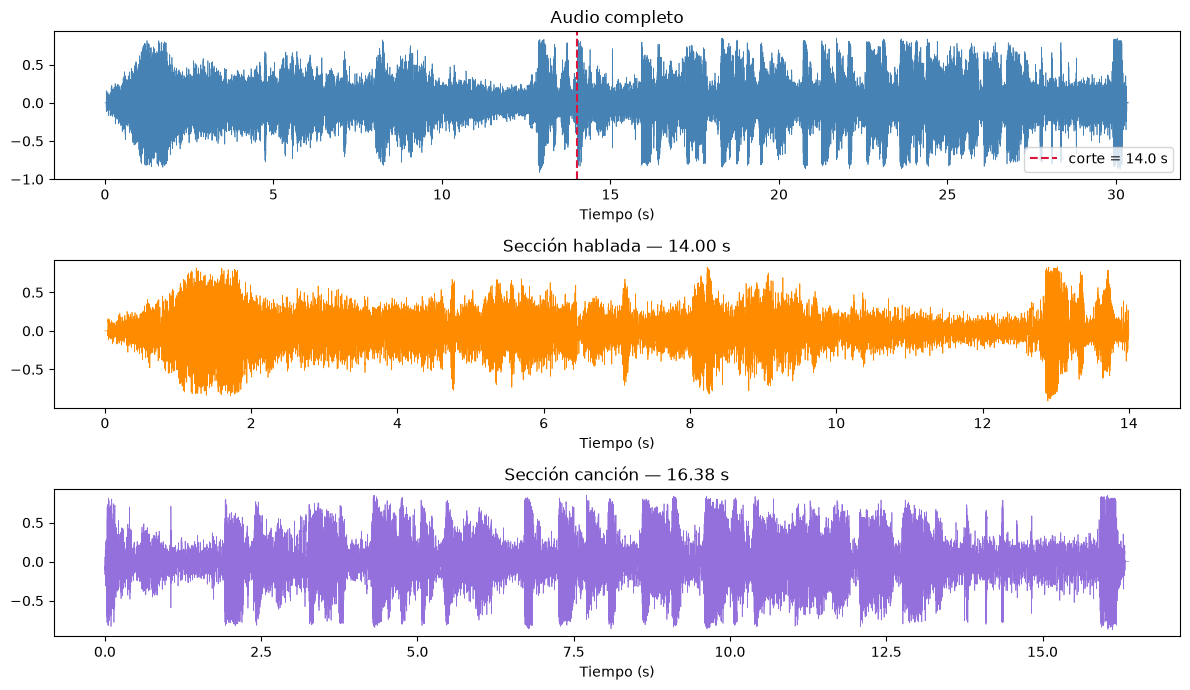

Escuchá el audio completo y después las dos secciones:


In [43]:
# ✏️ PASO 1: separá las dos secciones del audio.
# TODO: mové este valor y buscá el mejor punto de corte.
CORTE_S = 14

audio_demo = audio if audio.ndim == 1 else np.mean(audio, axis=1)
muestra_corte = int(CORTE_S * sr)
seccion_hablada = audio_demo[:muestra_corte]
seccion_cancion = audio_demo[muestra_corte:]

fig, ejes = plt.subplots(3, 1, figsize=(12, 7))
ejes[0].plot(np.arange(len(audio_demo)) / sr, audio_demo, lw=0.5, color="steelblue")
ejes[0].axvline(CORTE_S, color="crimson", ls="--", label=f"corte = {CORTE_S:.1f} s")
ejes[0].set_title("Audio completo")
ejes[0].set_xlabel("Tiempo (s)")
ejes[0].legend()
ejes[1].plot(np.arange(len(seccion_hablada)) / sr, seccion_hablada, lw=0.5, color="darkorange")
ejes[1].set_title(f"Sección hablada — {len(seccion_hablada) / sr:.2f} s")
ejes[1].set_xlabel("Tiempo (s)")
ejes[2].plot(np.arange(len(seccion_cancion)) / sr, seccion_cancion, lw=0.5, color="mediumpurple")
ejes[2].set_title(f"Sección canción — {len(seccion_cancion) / sr:.2f} s")
ejes[2].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

from IPython.display import Audio, display
print("Escuchá el audio completo y después las dos secciones:")
display(Audio(data=audio_demo, rate=sr))
display(Audio(data=seccion_hablada, rate=sr))
display(Audio(data=seccion_cancion, rate=sr))


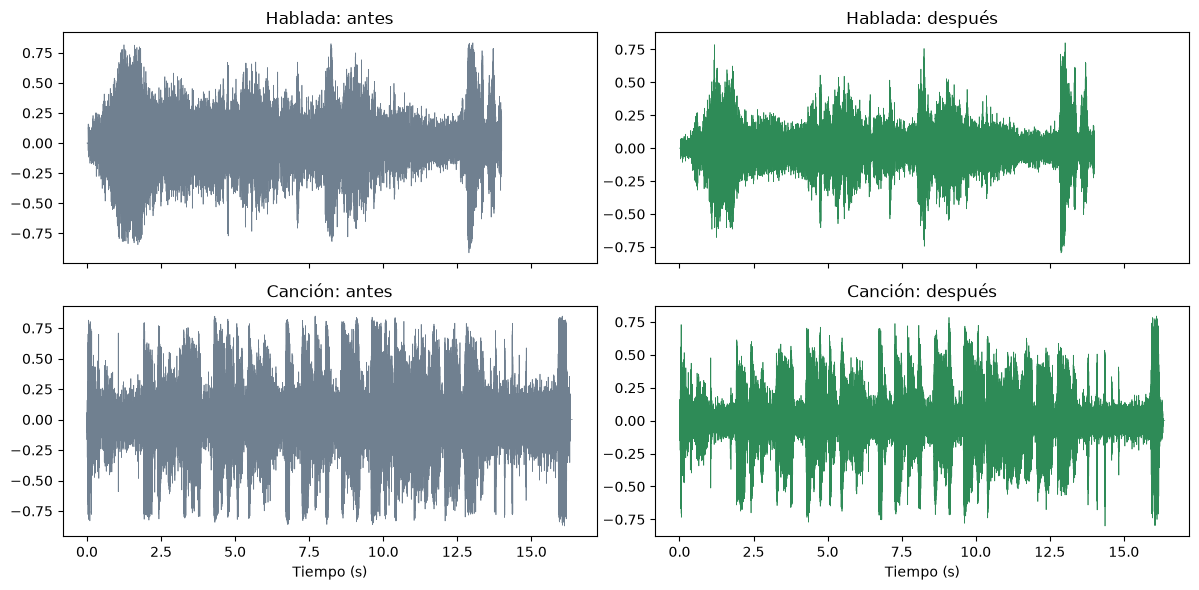

Escuchá antes y después para cada sección:


In [44]:
# ✏️ PASO 2: mejorá un poco la calidad y compará el resultado.
# TODO: probá distintas combinaciones sin perder demasiada voz ni música.
FRECUENCIA_CORTE_BAJAS_HZ = 100.0
FRECUENCIA_CORTE_ALTAS_HZ = 6500.0
ORDEN_FILTRO = 4
AMPLITUD_OBJETIVO = 0.80

def mejorar_calidad(señal, sr, frecuencia_bajas, frecuencia_altas, orden, amplitud_objetivo):
    """Atenúa extremos de frecuencia y ajusta el nivel final."""
    nyquist = sr / 2
    if not 0 < frecuencia_bajas < frecuencia_altas < nyquist:
        raise ValueError(f"Usá 0 < bajas < altas < {nyquist:.0f} Hz")
    sos = butter(
        orden,
        [frecuencia_bajas / nyquist, frecuencia_altas / nyquist],
        btype="bandpass",
        output="sos",
    )
    filtrada = sosfiltfilt(sos, señal)
    pico = np.max(np.abs(filtrada))
    if pico > 0:
        filtrada = filtrada * amplitud_objetivo / pico
    return filtrada

hablado_mejorado = mejorar_calidad(
    seccion_hablada, sr, FRECUENCIA_CORTE_BAJAS_HZ, FRECUENCIA_CORTE_ALTAS_HZ,
    ORDEN_FILTRO, AMPLITUD_OBJETIVO
)
cancion_mejorada = mejorar_calidad(
    seccion_cancion, sr, FRECUENCIA_CORTE_BAJAS_HZ, FRECUENCIA_CORTE_ALTAS_HZ,
    ORDEN_FILTRO, AMPLITUD_OBJETIVO
)

tabla_comparacion = pd.DataFrame([
    {"Sección": "Hablada", "Duración (s)": len(seccion_hablada) / sr, "RMS antes": rms(seccion_hablada), "RMS después": rms(hablado_mejorado)},
    {"Sección": "Canción", "Duración (s)": len(seccion_cancion) / sr, "RMS antes": rms(seccion_cancion), "RMS después": rms(cancion_mejorada)},
])
tabla_comparacion.round(3)

fig, ejes = plt.subplots(2, 2, figsize=(12, 6), sharex="col")
for fila, (antes, despues, titulo) in enumerate([
    (seccion_hablada, hablado_mejorado, "Hablada"),
    (seccion_cancion, cancion_mejorada, "Canción"),
]):
    ejes[fila, 0].plot(np.arange(len(antes)) / sr, antes, lw=0.5, color="slategray")
    ejes[fila, 0].set_title(f"{titulo}: antes")
    ejes[fila, 1].plot(np.arange(len(despues)) / sr, despues, lw=0.5, color="seagreen")
    ejes[fila, 1].set_title(f"{titulo}: después")
for ax in ejes[-1]:
    ax.set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

print("Escuchá antes y después para cada sección:")
display(Audio(data=seccion_hablada, rate=sr))
display(Audio(data=hablado_mejorado, rate=sr))
display(Audio(data=seccion_cancion, rate=sr))
display(Audio(data=cancion_mejorada, rate=sr))


### Para compartir al final

1. Mostrá tu flujo conceptual y explicá dónde guardarías las dos secciones.
2. Indicá qué valor elegiste para `CORTE_S` y qué evidencia usaste para decidirlo.
3. Indicá las frecuencias de corte elegidas y qué ruido intentaste reducir.
4. Explicá qué se mejoró y qué problema del audio original permanece.

> **Cierre:** un pipeline de audio útil combina una decisión de producto —qué hacer con cada archivo— con transformaciones concretas sobre la señal. En este laboratorio esas transformaciones son solamente separar y filtrar.


---

## Síntesis de la clase

- El audio digital es una secuencia de amplitudes muestreadas a un sample rate.
- La waveform muestra amplitud en el tiempo; el espectrograma muestra frecuencias en el tiempo.
- La STFT divide el audio en ventanas y calcula las frecuencias de cada una.
- Las features acústicas resumen el audio en números interpretables.
- Combinar features permite distinguir voz, tonos y silencios con reglas simples.
- Un pipeline puede validar, transformar y preparar un audio antes de enviarlo a otro componente.

## Comprobación conceptual

Antes de continuar, intentá responder sin mirar el notebook:

1. ¿Cuál era el problema central de la clase?
2. ¿Qué entrada recibió el sistema y qué salida produjo?
3. ¿Qué decisión humana siguió siendo necesaria?
4. ¿Qué limitación observaste en el experimento?

Si podés explicarlo con tus propias palabras y justificarlo con un resultado visible, alcanzaste el objetivo introductorio.

## Puente con la próxima clase

La clase 2 muestra cómo un modelo de reconocimiento de voz (Whisper) convierte esta señal en texto, y cómo un modelo de síntesis (TTS) hace el camino inverso: de texto a voz. Ese par es la base de los asistentes conversacionales del consultorio.

## Conexión con el track

Salud usará el espectrograma y las features acústicas para ASR, detección de turnos de habla y control de calidad de grabaciones.

La implementación profunda, el trabajo con datasets reales y las decisiones de producción se desarrollarán en los módulos especializados.
